In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore")

In [3]:
# !pip install xgboost

In [5]:
df = pd.read_csv ("cybersecurity_intrusion_data.csv")

In [7]:
df.head(5)

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [9]:
print("Initial shape:", df.shape)

df = df.drop_duplicates()
df = df.dropna(axis=0, how='all')     
df = df.fillna(df.median(numeric_only=True)) 
df = df.fillna("Unknown")            
print("After cleaning:", df.shape)

Initial shape: (9537, 11)
After cleaning: (9537, 11)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      9537 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 894.1+ KB


In [13]:
if 'session_id' in df.columns:
    df = df.drop('session_id', axis=1)

# ===================== 4. Define Feature Groups =====================
numerical_features = ["network_packet_size", "login_attempts", "session_duration", 
                      "ip_reputation_score", "failed_logins"]
categorical_features = ["protocol_type", "encryption_used", "browser_type"]
binary_features = ["unusual_time_access"]  # already binary
target_variable = "attack_detected"
df[numerical_features] = df[numerical_features].fillna(df[numerical_features].median())
df[categorical_features] = df[categorical_features].fillna("Unknown")

# ===================== 6. One-Hot Encode Categorical Features =====================
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [15]:
print(df.isnull().sum())

network_packet_size     0
login_attempts          0
session_duration        0
ip_reputation_score     0
failed_logins           0
unusual_time_access     0
attack_detected         0
protocol_type_TCP       0
protocol_type_UDP       0
encryption_used_DES     0
encryption_used_None    0
browser_type_Edge       0
browser_type_Firefox    0
browser_type_Safari     0
browser_type_Unknown    0
dtype: int64


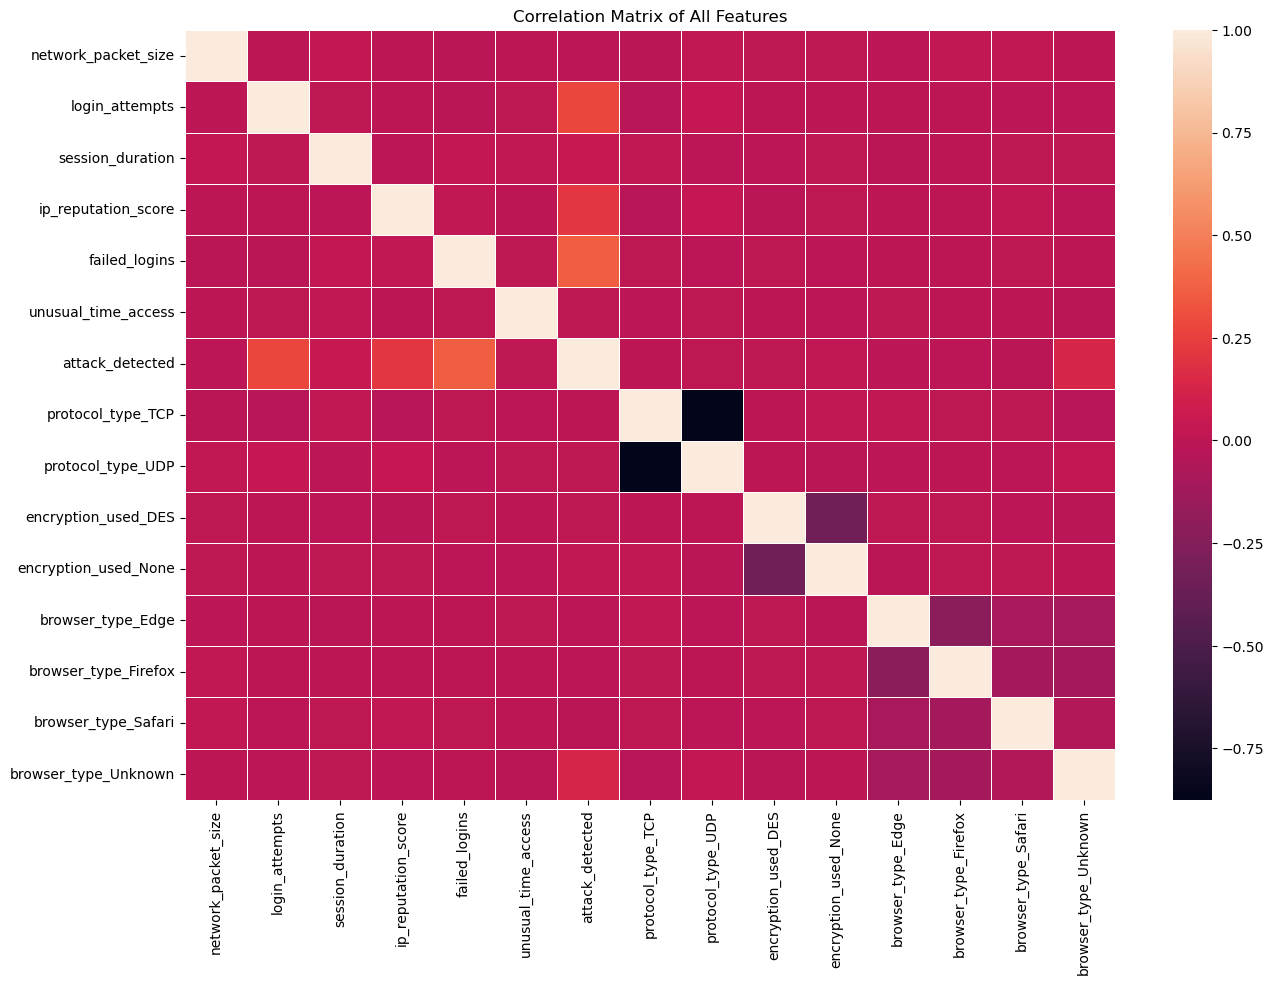

In [17]:
plt.figure(figsize=(15, 10))
corr = df.corr()
sns.heatmap(corr, annot=False, linewidths=0.5)
plt.title("Correlation Matrix of All Features")
plt.show()

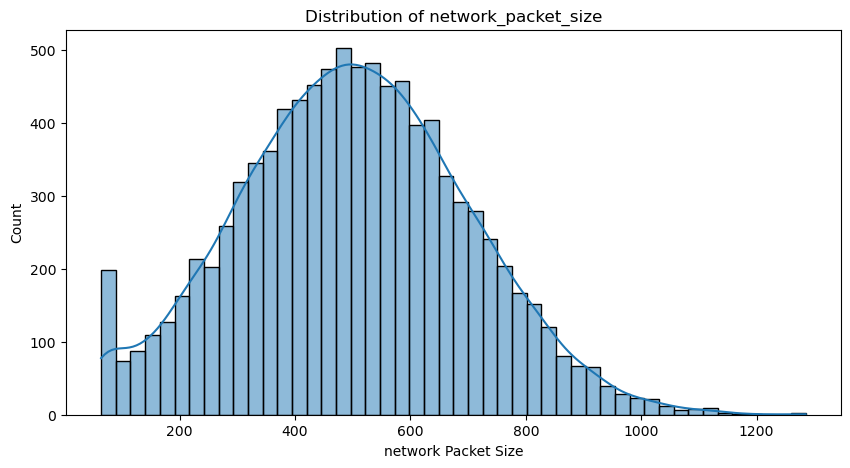

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df["network_packet_size"],kde=True)
plt.xlabel("network Packet Size")
plt.ylabel("Count")
plt.title("Distribution of network_packet_size")
plt.show()

0    5273
1    4264
Name: attack_detected, dtype: int64


<Axes: >

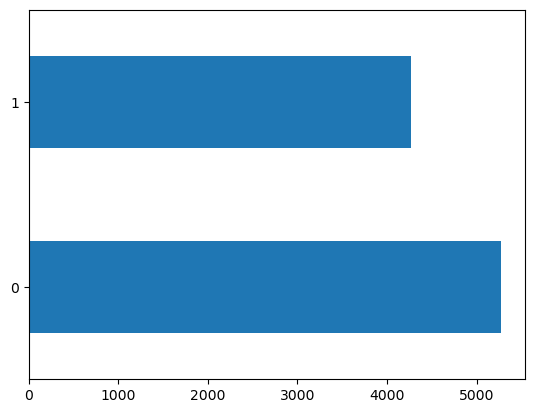

In [19]:
print(df['attack_detected'].value_counts())
df['attack_detected'].value_counts().plot(kind='barh')

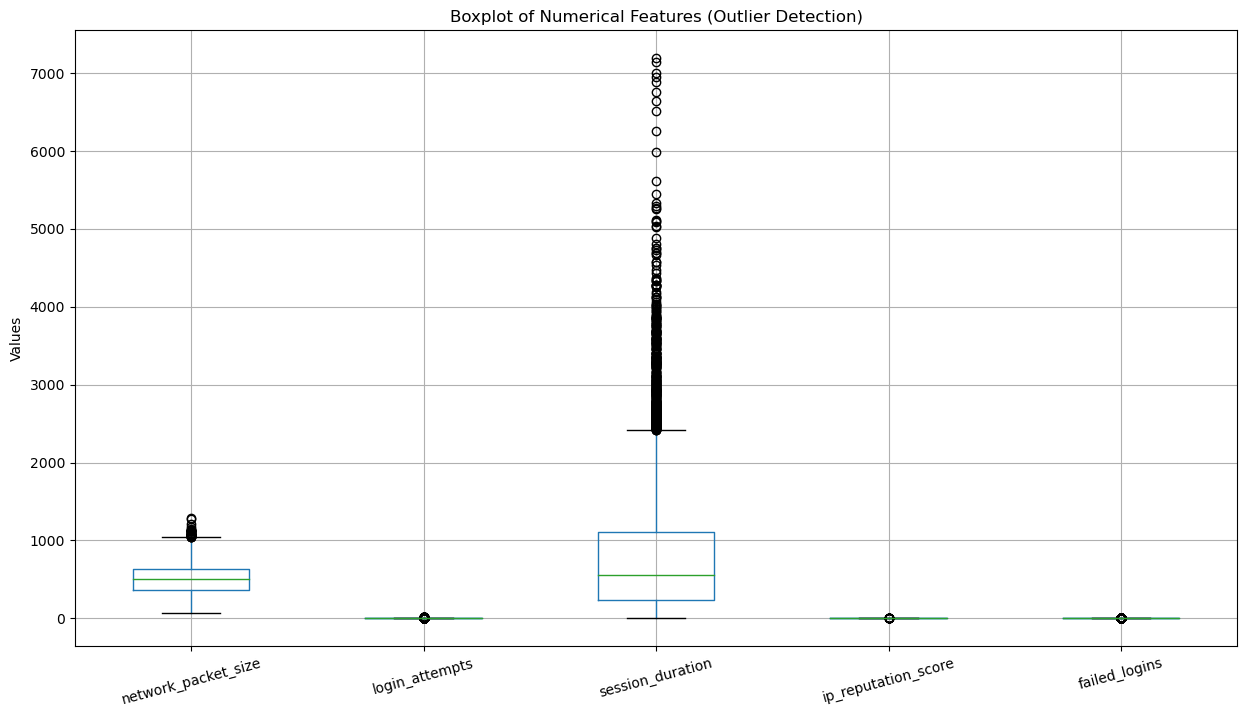

In [20]:
plt.figure(figsize=(15, 8))
df[numerical_features].boxplot()
plt.xticks(rotation=15)
plt.title("Boxplot of Numerical Features (Outlier Detection)")
plt.ylabel("Values")
plt.show()

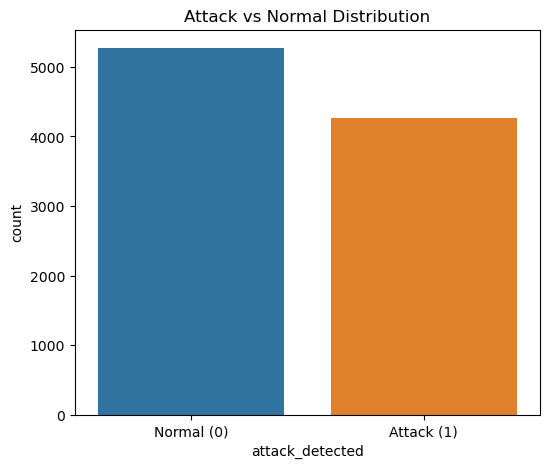

In [21]:
plt.figure(figsize=(6, 5))
sns.countplot(x="attack_detected", data=df)
plt.title("Attack vs Normal Distribution")
plt.xticks([0, 1], ["Normal (0)", "Attack (1)"])
plt.show()

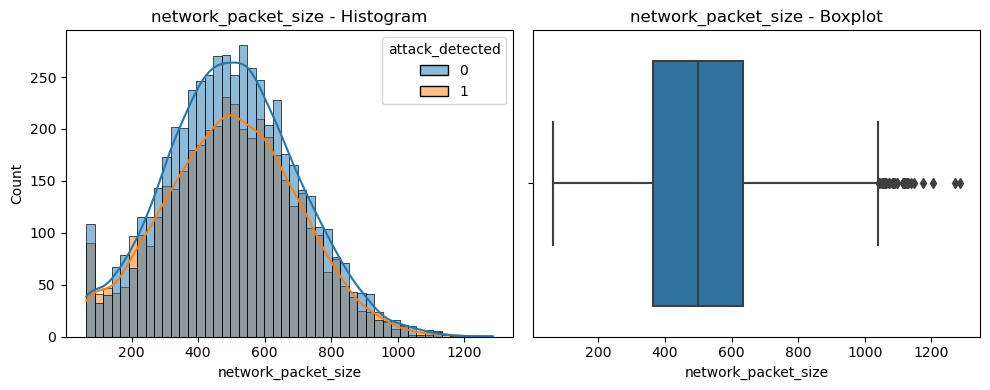

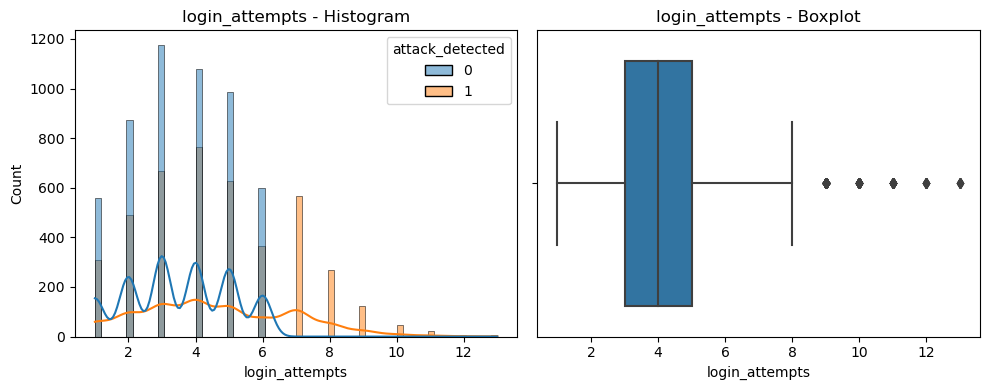

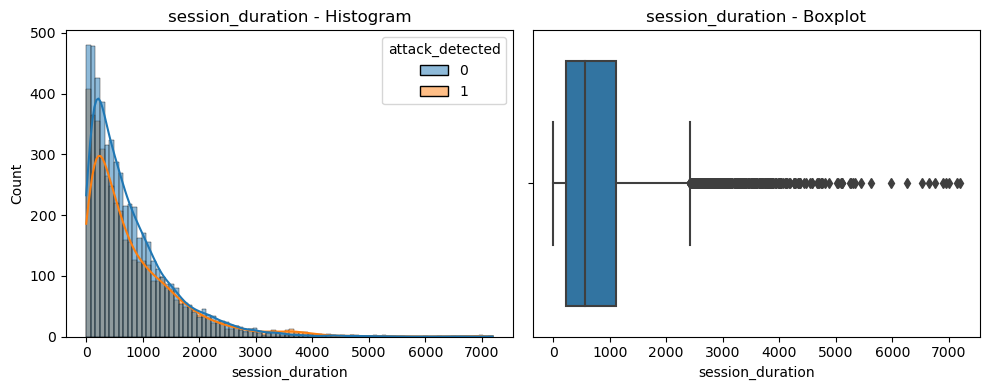

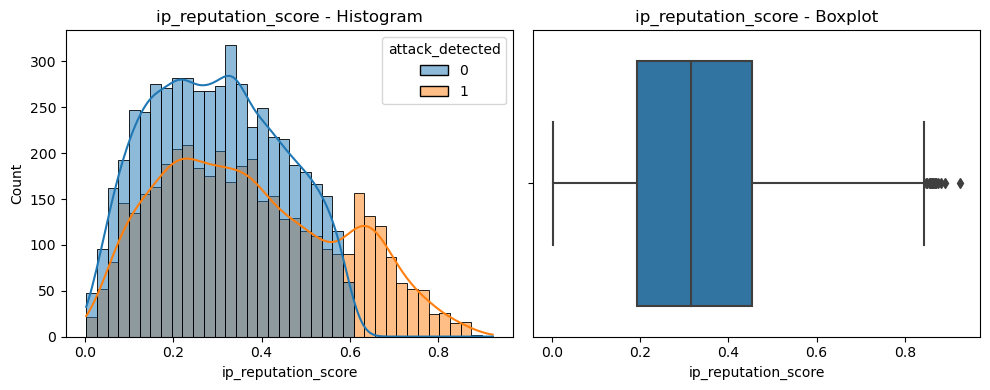

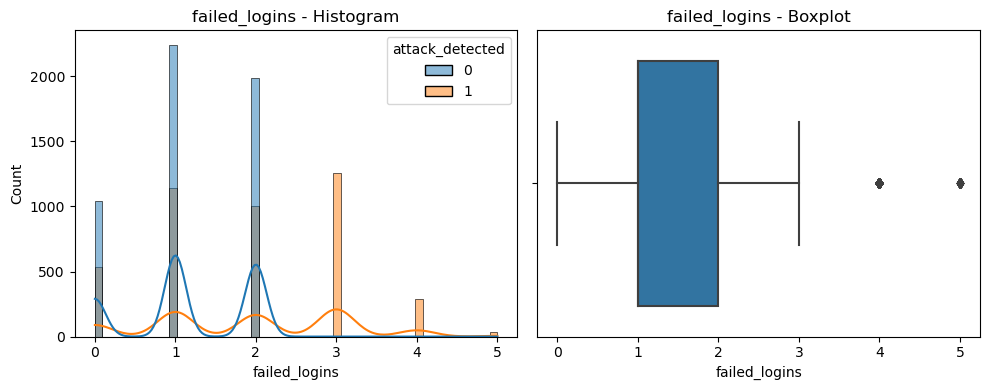

In [22]:
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
for c in num_cols[:5]:  # show only first 5 numeric columns
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=c, hue=target_variable, kde=True)
    plt.title(f"{c} - Histogram")
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[c])
    plt.title(f"{c} - Boxplot")
    plt.tight_layout()
    plt.show()

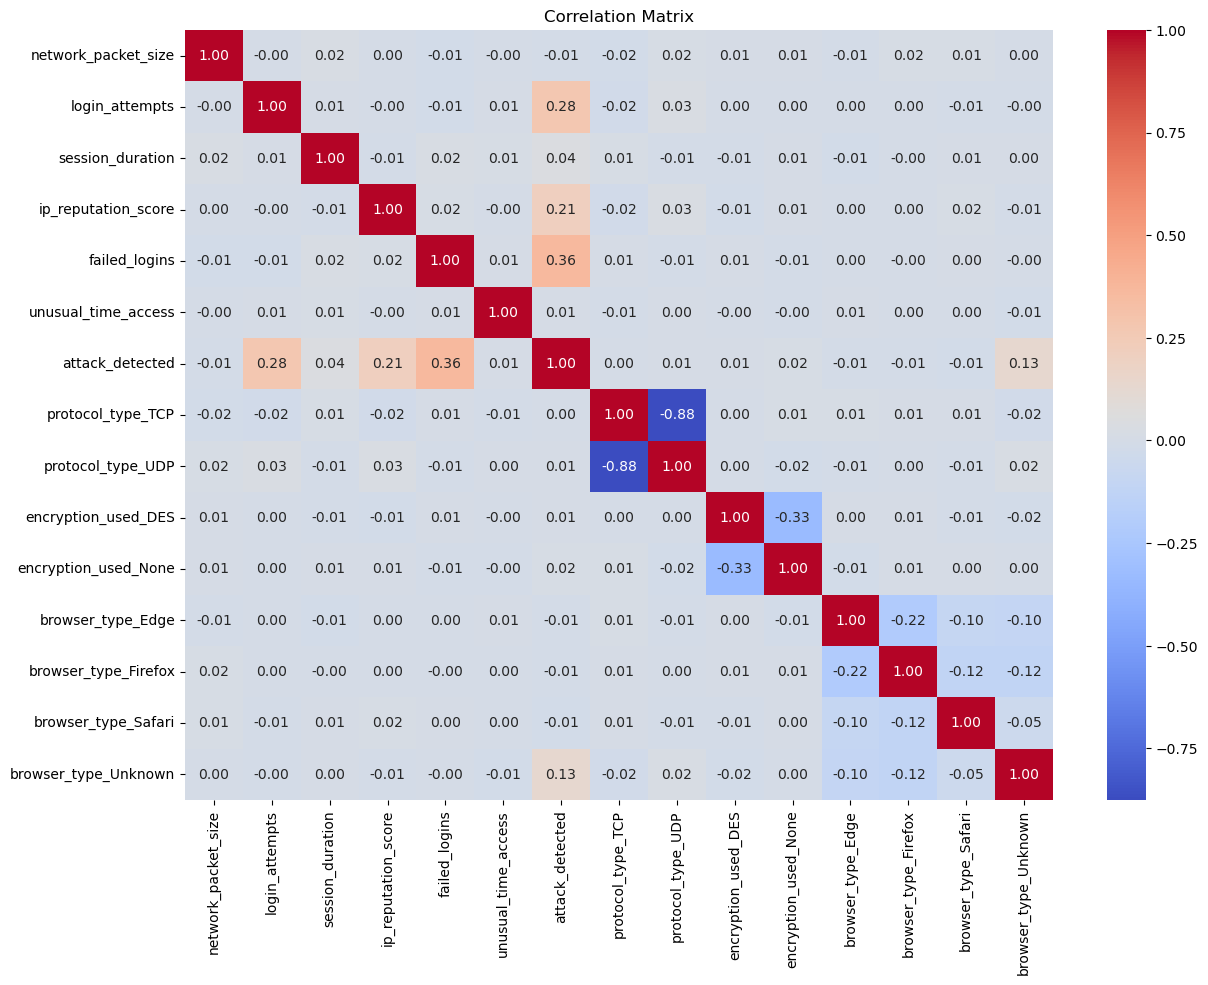

In [23]:
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [25]:
X = df.drop(columns=[target_variable])
y = df[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])


print("Class Distribution in Train Set:")
print(y_train.value_counts(normalize=True))

print("Class Distribution in Test Set:")
print(y_test.value_counts(normalize=True))

Class Distribution in Train Set:
0    0.55289
1    0.44711
Name: attack_detected, dtype: float64
Class Distribution in Test Set:
0    0.552935
1    0.447065
Name: attack_detected, dtype: float64


In [26]:
import time
import pickle
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}


results = {}

print("Starting model training and evaluation...")
print("-" * 30)

for name, model in models.items():
    print(f"Evaluating: {name}...")
    
    train_start = time.time()
    model.fit(X_train, y_train)
    train_end = time.time()
    train_time = train_end - train_start

    pred_start = time.time()
    y_pred = model.predict(X_test)
    pred_end = time.time()
    pred_time = pred_end - pred_start

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = np.zeros(len(y_pred))
        auc = 0.0 

    pickled_model = pickle.dumps(model)
    model_memory_mb = len(pickled_model) / (1024 * 1024) 
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": auc,
        "Train Time (s)": train_time,
        "Predict Time (s)": pred_time,
        "Model Size (MB)": model_memory_mb
    }

print("-" * 30)
print("Evaluation complete.")

results_df = pd.DataFrame(results).T

columns_order = [
    "Accuracy", "Precision", "Recall", "F1 Score", "AUC",
    "Train Time (s)", "Predict Time (s)", "Model Size (MB)"
]
results_df = results_df[columns_order]

print("\n=== Model Performance Comparison ===\n")

print(results_df.to_string(float_format="{:,.4f}".format))

Starting model training and evaluation...
------------------------------
Evaluating: Logistic Regression...
Evaluating: Random Forest...
Evaluating: SVM...
Evaluating: KNN...
Evaluating: XGBoost...
------------------------------
Evaluation complete.

=== Model Performance Comparison ===

                     Accuracy  Precision  Recall  F1 Score    AUC  Train Time (s)  Predict Time (s)  Model Size (MB)
Logistic Regression    0.7290     0.7193  0.6460    0.6807 0.7876          0.0620            0.0010           0.0011
Random Forest          0.8863     0.9969  0.7479    0.8547 0.8800          5.6407            0.1569          16.4134
SVM                    0.8737     0.9665  0.7433    0.8403 0.8730         30.7626            2.0012           0.3899
KNN                    0.8014     0.8624  0.6612    0.7485 0.8356          0.0762            0.6253           0.9950
XGBoost                0.8821     0.9758  0.7550    0.8513 0.8813          2.7916            0.0113           0.2251


<Figure size 1000x600 with 0 Axes>

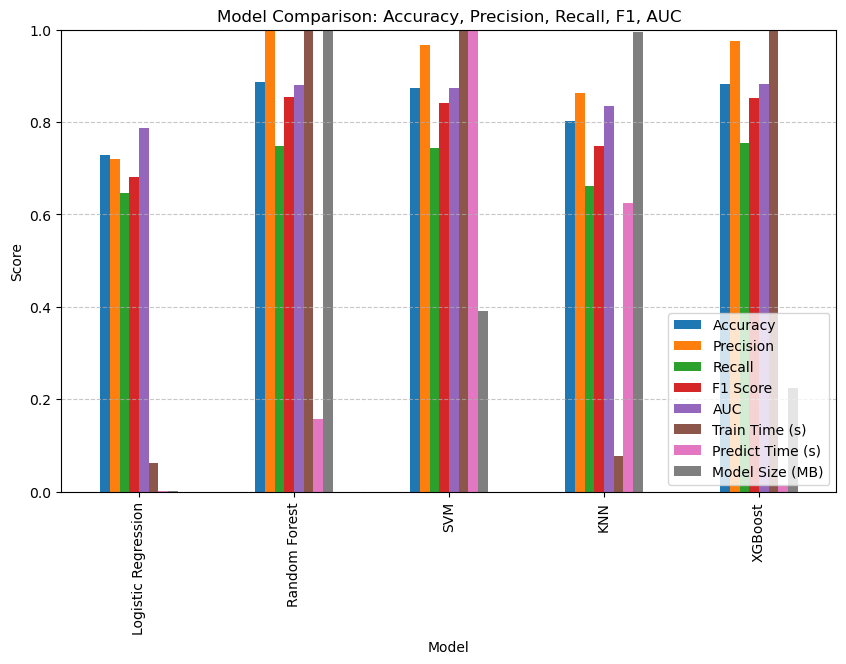

In [27]:
plt.figure(figsize=(10, 6))
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison: Accuracy, Precision, Recall, F1, AUC")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

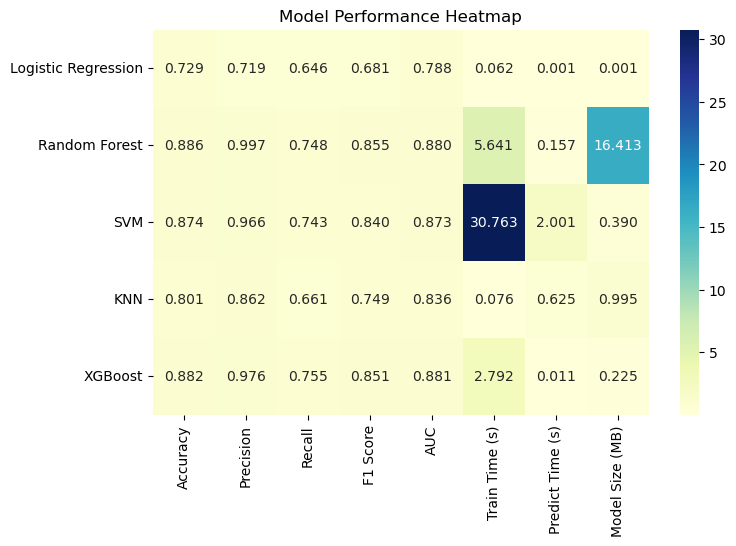

In [29]:
plt.figure(figsize=(8, 5))
sns.heatmap(results_df, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Model Performance Heatmap")
plt.show()

In [31]:
from sklearn.metrics import f1_score

print("\n=== F1-Scores of All Models ===")
for name, model in models.items():
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    print(f"{name}: F1 Score = {f1:.4f}")



=== F1-Scores of All Models ===
Logistic Regression: F1 Score = 0.6807
Random Forest: F1 Score = 0.8547
SVM: F1 Score = 0.8403
KNN: F1 Score = 0.7485
XGBoost: F1 Score = 0.8513


In [45]:
import joblib
xgb_model = models["XGBoost"]

joblib.dump(xgb_model, "xgboost_model.pkl")

print("XGBoost model saved as xgboost_model.pkl")

XGBoost model saved as xgboost_model.pkl


In [47]:
scaler = StandardScaler()

In [49]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']